# Download the file

In [1]:
import pandas as  pd
final_ml_df = pd.read_csv(r"F:\downloads microsodt\GSE108966_RIF_ml_dataset.csv") 
#Use raw string r"..." for Windows paths so backslashes are handled correctly.


display(final_ml_df.head(5))
print("shape of the df:", final_ml_df.shape)
print("df info:")
final_ml_df.info()

,Sample,GSM_ID,Tissue,Patient_ID,LH_Day,Condition,hsa-let-7a-3p,hsa-let-7a-5p,hsa-let-7a-2-3p,hsa-let-7b-5p,...,hsa-miR-95-5p,hsa-miR-95-3p,hsa-miR-96-5p,hsa-miR-96-3p,hsa-miR-98-3p,hsa-miR-98-5p,hsa-miR-99a-3p,hsa-miR-99a-5p,hsa-miR-99b-5p,hsa-miR-99b-3p
0,13586,GSM2916723,endometrium,8,2,CONTROL,289,775079,2,89304,...,14,329,1150,0,34,37013,1034,17456,31791,552
1,13590,GSM2916724,endometrium,8,8,CONTROL,525,182340,2,31151,...,6,115,283,1,39,7448,236,3941,4653,184
2,13606,GSM2916725,blood,8,2,CONTROL,47,20735,0,1003,...,0,3,0,0,38,1164,2,10,902,16
3,13610,GSM2916726,blood,8,8,CONTROL,40,17309,0,1387,...,0,3,0,0,27,1127,1,16,1171,8
4,13879,GSM2916727,endometrium,11,2,CONTROL,314,168588,4,24902,...,1,113,147,0,33,6240,271,4257,14182,239


shape of the df: (91, 2594)
df info:
<class 'pandas.DataFrame'>
RangeIndex: 91 entries, 0 to 90
Columns: 2594 entries, Sample to hsa-miR-99b-3p
dtypes: int64(2591), str(3)
memory usage: 1.8 MB


# ML workflow - dataset cleaning and filter

In [2]:
final_ml_df['Label'] = final_ml_df['Condition'].map({
    'CONTROL': 0,
    'IVF': 1
})

print(final_ml_df[['Condition', 'Label']].head())
print(final_ml_df["Label"].value_counts())


  Condition  Label
0   CONTROL      0
1   CONTROL      0
2   CONTROL      0
3   CONTROL      0
4   CONTROL      0
Label
0    62
1    29
Name: count, dtype: int64


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13232\1629844215.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  final_ml_df['Label'] = final_ml_df['Condition'].map({


In [3]:
metadata_cols = [
    'Sample',
    'GSM_ID',
    'Tissue',
    'Patient_ID',
    'LH_Day',
    'Condition',
    'Label'
]

X = final_ml_df.drop(columns=metadata_cols)

y = final_ml_df['Label']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (91, 2588)
y shape: (91,)


In [4]:
print("Missing values in X:", X.isnull().sum().sum())

print("Missing values in y:", y.isnull().sum())

Missing values in X: 0
Missing values in y: 0


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\ny_train distribution:")
print(y_train.value_counts())

print("\ny_test distribution:")
print(y_test.value_counts())

X_train: (72, 2588)
X_test: (19, 2588)

y_train distribution:
Label
0    49
1    23
Name: count, dtype: int64

y_test distribution:
Label
0    13
1     6
Name: count, dtype: int64


In [6]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)

selector = VarianceThreshold(threshold=0.01)

X_train_var = selector.fit_transform(X_train)
X_test_var = selector.transform(X_test)


print("Original shape:", X_train.shape)
print("After variance filtering:", X_train_var.shape)


print("Original shape:", X_test.shape)
print("After variance filtering:", X_test_var.shape)

Original shape: (72, 2588)
After variance filtering: (72, 2211)
Original shape: (19, 2588)
After variance filtering: (19, 2211)


In [7]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()

X_train_scale = scaler.fit_transform(X_train_var)
X_test_scale = scaler.transform(X_test_var)

print(X_train_scale.shape)
print(X_test_scale.shape)


(72, 2211)
(19, 2211)


In [8]:
from sklearn.feature_selection import SelectKBest, f_classif

selector_kbest = SelectKBest(score_func=f_classif, k=100)

X_train_selected = selector_kbest.fit_transform(X_train_scale, y_train)

X_test_selected = selector_kbest.transform(X_test_scale)

print("X_train_selected:", X_train_selected.shape)
print("X_test_selected:", X_test_selected.shape)

X_train_selected: (72, 100)
X_test_selected: (19, 100)


# Model building #1

In [9]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train_selected)

# Transform test data
X_test_scaled = scaler.transform(X_test_selected)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(72, 100)
(19, 100)


In [10]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Create SVM model
svm_model = SVC(
    kernel='linear',
    class_weight='balanced',
    random_state=42
)

# Train
svm_model.fit(X_train_scaled, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_svm))

Accuracy: 0.7894736842105263

Classification Report:



              precision    recall  f1-score   support

           0       0.85      0.85      0.85        13
           1       0.67      0.67      0.67         6

    accuracy                           0.79        19
   macro avg       0.76      0.76      0.76        19
weighted avg       0.79      0.79      0.79        19


Confusion Matrix:

[[11  2]
 [ 2  4]]


In [11]:
import pandas as pd
import numpy as np

# Get feature importance from linear SVM
importance = np.abs(svm_model.coef_[0])

# Get the feature names that passed the VarianceThreshold
features_after_variance = X.columns[selector.get_support()]

# Get the names of the top K features selected by SelectKBest
selected_features = features_after_variance[selector_kbest.get_support()]

# Create dataframe
feature_importance_df = pd.DataFrame({
    'miRNA': selected_features,
    'Importance': importance
})

# Sort descending
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Top 20 biomarkers
top20 = feature_importance_df.head(20)

display(top20)

,miRNA,Importance
27,hsa-miR-3146,0.726273
4,hsa-miR-106a-3p,0.620811
28,hsa-miR-320c,0.529195
24,hsa-miR-29b-3p,0.516040
51,hsa-miR-4478,0.460442
74,hsa-miR-548am-3p,0.437828
37,hsa-miR-376b-3p,0.422051
75,hsa-miR-548f-3p,0.391992
89,hsa-miR-6868-3p,0.389449
55,hsa-miR-4488,0.388683


In [12]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Stratified K-Fold
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Cross-validation accuracy
cv_scores = cross_val_score(
    svm_model,
    X_train_scaled,
    y_train,
    cv=skf,
    scoring='accuracy'
)

print("Cross-validation scores:")
print(cv_scores)

print("\nMean CV Accuracy:")
print(cv_scores.mean())

print("\nStandard Deviation:")
print(cv_scores.std())

Cross-validation scores:
[0.6        0.8        0.57142857 0.85714286 0.85714286]

Mean CV Accuracy:
0.7371428571428571

Standard Deviation:
0.1257142857142857


AUC Score: 0.7307692307692307


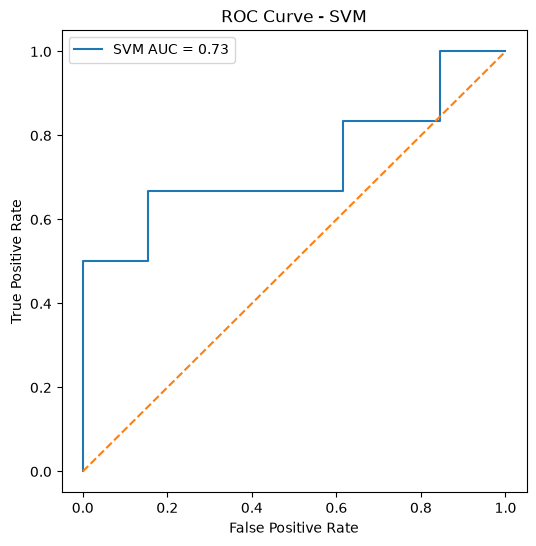

In [13]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probability-like scores
y_scores = svm_model.decision_function(X_test_scaled)

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# AUC
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

# Plot
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"SVM AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()

plt.show()

In [14]:


import shap
import numpy as np

# Create explainer
explainer = shap.LinearExplainer(
    svm_model,
    X_train_scaled
)

# SHAP values
shap_values = explainer.shap_values(X_test_scaled)

print(np.array(shap_values).shape)

c:\Users\LENOVO\anaconda3\envs\biomarker\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(19, 100)


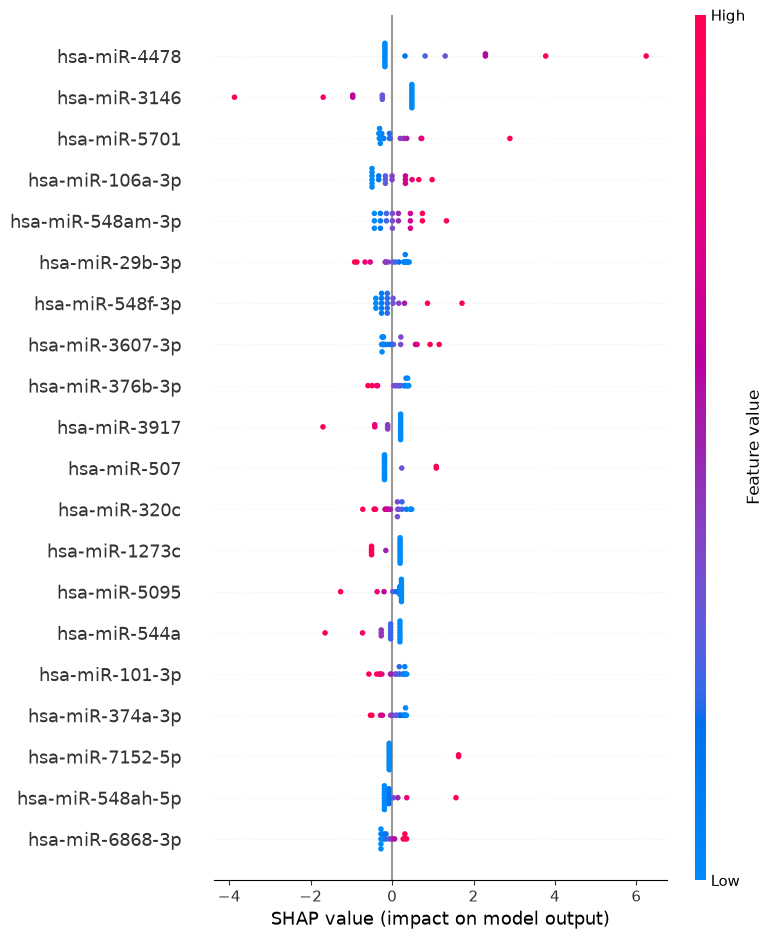

In [15]:
import matplotlib.pyplot as plt

# Summary plot
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=selected_features
)

In [16]:
# Mean absolute SHAP importance
shap_importance = np.abs(shap_values).mean(axis=0)

# Create dataframe
shap_df = pd.DataFrame({
    'miRNA': selected_features,
    'SHAP_Importance': shap_importance
})

# Sort
shap_df = shap_df.sort_values(
    by='SHAP_Importance',
    ascending=False
)

# Top biomarkers
display(shap_df.head(20))

,miRNA,SHAP_Importance
51,hsa-miR-4478,1.008453
27,hsa-miR-3146,0.739015
77,hsa-miR-5701,0.427146
4,hsa-miR-106a-3p,0.380765
74,hsa-miR-548am-3p,0.365698
24,hsa-miR-29b-3p,0.355611
75,hsa-miR-548f-3p,0.326351
30,hsa-miR-3607-3p,0.315774
37,hsa-miR-376b-3p,0.306107
41,hsa-miR-3917,0.294001


# Model building #2

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Logistic Regression model
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=5000,
    random_state=42
)

# Train
lr_model.fit(X_train_scaled, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lr))

Accuracy: 0.7368421052631579

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.77      0.80        13
           1       0.57      0.67      0.62         6

    accuracy                           0.74        19
   macro avg       0.70      0.72      0.71        19
weighted avg       0.75      0.74      0.74        19


Confusion Matrix:

[[10  3]
 [ 2  4]]


In [18]:
from sklearn.model_selection import cross_val_score

# Cross-validation
lr_cv_scores = cross_val_score(
    lr_model,
    X_train_scaled,
    y_train,
    cv=skf,
    scoring='accuracy'
)

print("CV Scores:")
print(lr_cv_scores)

print("\nMean CV Accuracy:")
print(lr_cv_scores.mean())

print("\nSTD:")
print(lr_cv_scores.std())

CV Scores:
[0.86666667 0.93333333 0.64285714 0.92857143 0.71428571]

Mean CV Accuracy:
0.8171428571428573

STD:
0.11774910873424796


Logistic Regression AUC: 0.7564102564102564


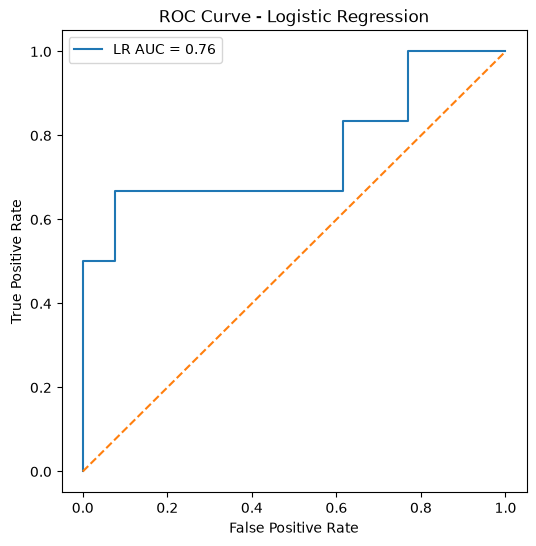

In [19]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probability scores
y_scores_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# ROC
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_scores_lr)

# AUC
roc_auc_lr = auc(fpr_lr, tpr_lr)

print("Logistic Regression AUC:", roc_auc_lr)

# Plot
plt.figure(figsize=(6,6))

plt.plot(fpr_lr, tpr_lr,
         label=f"LR AUC = {roc_auc_lr:.2f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

In [20]:
import numpy as np
import pandas as pd

# Coefficient importance
lr_importance = np.abs(lr_model.coef_[0])

# Create dataframe
lr_biomarkers = pd.DataFrame({
    'miRNA': selected_features,
    'Coefficient_Importance': lr_importance
})

# Sort
lr_biomarkers = lr_biomarkers.sort_values(
    by='Coefficient_Importance',
    ascending=False
)

# Top biomarkers
display(lr_biomarkers.head(20))


,miRNA,Coefficient_Importance
27,hsa-miR-3146,0.844359
77,hsa-miR-5701,0.794248
62,hsa-miR-4706,0.681518
30,hsa-miR-3607-3p,0.638348
6,hsa-miR-1247-3p,0.594943
90,hsa-miR-7152-5p,0.546415
55,hsa-miR-4488,0.537722
24,hsa-miR-29b-3p,0.497444
12,hsa-miR-135a-3p,0.491980
8,hsa-miR-1273d,0.484991


In [21]:
import shap
import numpy as np

# Explainer
lr_explainer = shap.LinearExplainer(
    lr_model,
    X_train_scaled
)

# SHAP values
lr_shap_values = lr_explainer.shap_values(X_test_scaled)

print(np.array(lr_shap_values).shape)

(19, 100)


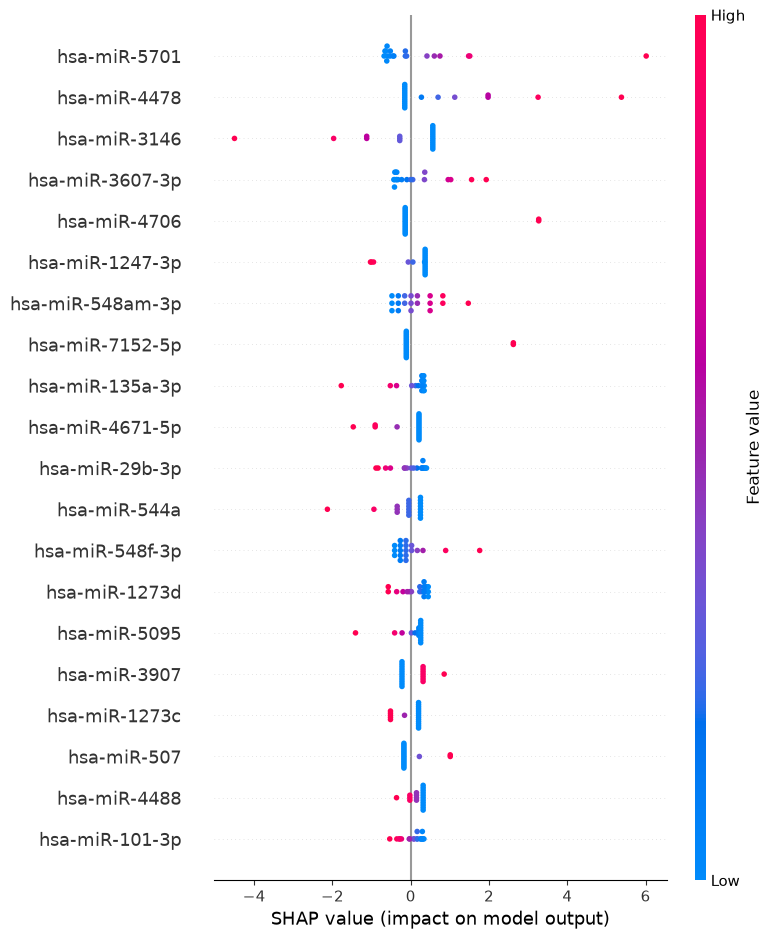

In [22]:
import matplotlib.pyplot as plt

# SHAP summary plot
shap.summary_plot(
    lr_shap_values,
    X_test_scaled,
    feature_names=selected_features
)

In [23]:
# Mean absolute SHAP importance
lr_shap_importance = np.abs(lr_shap_values).mean(axis=0)

# DataFrame
lr_shap_df = pd.DataFrame({
    'miRNA': selected_features,
    'SHAP_Importance': lr_shap_importance
})

# Sort
lr_shap_df = lr_shap_df.sort_values(
    by='SHAP_Importance',
    ascending=False
)

# Display top biomarkers
display(lr_shap_df.head(20))



,miRNA,SHAP_Importance
77,hsa-miR-5701,0.888151
51,hsa-miR-4478,0.869730
27,hsa-miR-3146,0.859173
30,hsa-miR-3607-3p,0.526993
62,hsa-miR-4706,0.471195
6,hsa-miR-1247-3p,0.432831
74,hsa-miR-548am-3p,0.403141
90,hsa-miR-7152-5p,0.377786
12,hsa-miR-135a-3p,0.370347
61,hsa-miR-4671-5p,0.357190


#comparison of models

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract metrics for SVM
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_report = classification_report(y_test, y_pred_svm, output_dict=True)
svm_precision = svm_report['macro avg']['precision']
svm_recall = svm_report['macro avg']['recall']
svm_f1 = svm_report['macro avg']['f1-score']
# roc_auc for SVM is roc_auc from cell vQ16YF6OQgZ5
svm_auc = roc_auc
# Mean CV Accuracy for SVM is cv_scores.mean() from cell 21DUFM5dQUib
svm_cv_mean_accuracy = cv_scores.mean()

# Extract metrics for Logistic Regression
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_report = classification_report(y_test, y_pred_lr, output_dict=True)
lr_precision = lr_report['macro avg']['precision']
lr_recall = lr_report['macro avg']['recall']
lr_f1 = lr_report['macro avg']['f1-score']
# roc_auc_lr for Logistic Regression is roc_auc_lr from cell CjqPIuIkR_lM
lr_auc = roc_auc_lr
# Mean CV Accuracy for Logistic Regression is lr_cv_scores.mean() from cell iIUREe42R2S6
lr_cv_mean_accuracy = lr_cv_scores.mean()

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy (Test Set)', 'Precision (Macro Avg)', 'Recall (Macro Avg)', 'F1-score (Macro Avg)', 'AUC (Test Set)', '5-fold CV Mean Accuracy'],
    'SVM': [
        f'{svm_accuracy:.2f}',
        f'{svm_precision:.2f}',
        f'{svm_recall:.2f}',
        f'{svm_f1:.2f}',
        f'{svm_auc:.2f}',
        f'{svm_cv_mean_accuracy:.2f}'
    ],
    'Logistic Regression': [
        f'{lr_accuracy:.2f}',
        f'{lr_precision:.2f}',
        f'{lr_recall:.2f}',
        f'{lr_f1:.2f}',
        f'{lr_auc:.2f}',
        f'{lr_cv_mean_accuracy:.2f}'
    ]
})

display(comparison_df)

# Visualize the table as an image for a research paper
fig, ax = plt.subplots(figsize=(10, 4)) # Adjust size as needed
ax.axis('off') # Hide axes

# Create the table
table = ax.table(
    cellText=comparison_df.values,
    colLabels=comparison_df.columns,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2) # Scale for better readability

ax.set_title('Model Performance Comparison', fontsize=16, pad=20)

plt.tight_layout()
plt.close()

print("Model comparison table saved as 'model_comparison_table.png'")

,Metric,SVM,Logistic Regression
0,Accuracy (Test Set),0.79,0.74
1,Precision (Macro Avg),0.76,0.70
2,Recall (Macro Avg),0.76,0.72
3,F1-score (Macro Avg),0.76,0.71
4,AUC (Test Set),0.73,0.76
5,5-fold CV Mean Accuracy,0.74,0.82


Model comparison table saved as 'model_comparison_table.png'


In [25]:
comparison_df1 = comparison_df.T
display(comparison_df1)


,0,1,2,3,4,5
Metric,Accuracy (Test Set),Precision (Macro Avg),Recall (Macro Avg),F1-score (Macro Avg),AUC (Test Set),5-fold CV Mean Accuracy
SVM,0.79,0.76,0.76,0.76,0.73,0.74
Logistic Regression,0.74,0.70,0.72,0.71,0.76,0.82


# comparision of biomarkers

In [26]:
# Top 20 from each method

svm_top = set(feature_importance_df.head(20)['miRNA'])

svm_shap_top = set(shap_df.head(20)['miRNA'])

lr_top = set(lr_biomarkers.head(20)['miRNA'])

lr_shap_top = set(lr_shap_df.head(20)['miRNA'])

print("Done")

Done


In [27]:
# Find consensus biomarkers

consensus = (
    svm_top &
    svm_shap_top &
    lr_top &
    lr_shap_top
)

print("Consensus Biomarkers:\n")
print(consensus)

print("\nNumber of consensus biomarkers:")
print(len(consensus))

Consensus Biomarkers:

{'hsa-miR-29b-3p', 'hsa-miR-4478', 'hsa-miR-3146', 'hsa-miR-3607-3p', 'hsa-miR-548am-3p', 'hsa-miR-5701', 'hsa-miR-7152-5p', 'hsa-miR-5095', 'hsa-miR-1273c', 'hsa-miR-548f-3p'}

Number of consensus biomarkers:
10


In [28]:
# Convert to dataframe
consensus_df = pd.DataFrame({
    'Consensus_miRNA': list(consensus)
})

display(consensus_df)



,Consensus_miRNA
0,hsa-miR-29b-3p
1,hsa-miR-4478
2,hsa-miR-3146
3,hsa-miR-3607-3p
4,hsa-miR-548am-3p
5,hsa-miR-5701
6,hsa-miR-7152-5p
7,hsa-miR-5095
8,hsa-miR-1273c
9,hsa-miR-548f-3p


# evaluation with deSeq

In [29]:
res = pd.read_csv(r"F:\downloads microsodt\DESeq2_results.csv")

display(res.head(5))
display(res.shape)

,Unnamed: 0,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,hsa.miR.4485.3p,262.395421,6.367132,0.535257,11.895458,1.249663e-32,1.665800e-29
1,hsa.miR.5701,83.148010,1.796157,0.220865,8.132365,4.209939e-16,2.805924e-13
2,hsa.miR.5585.3p,24.489868,3.449230,0.437013,7.892731,2.956433e-15,1.313642e-12
3,hsa.miR.4484,3.453891,3.358624,0.442776,7.585381,3.315115e-14,1.104762e-11
4,hsa.miR.4284,5.940096,4.813253,0.655746,7.340118,2.134062e-13,5.689410e-11


(2588, 7)

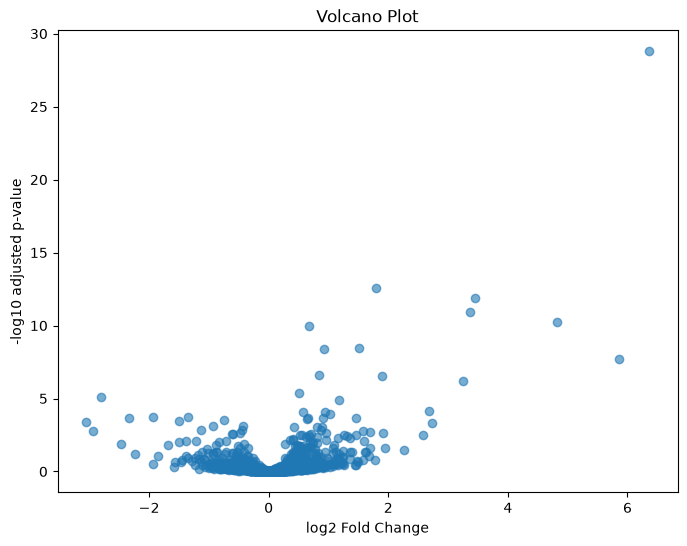

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

res = pd.read_csv(r"F:\downloads microsodt\DESeq2_results.csv")

plt.figure(figsize=(8,6))

plt.scatter(
    res["log2FoldChange"],
    -np.log10(res["padj"]),
    alpha=0.6
)

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 adjusted p-value")
plt.title("Volcano Plot")

plt.show()

In [31]:
sig = res[
    (res["padj"] < 0.05) &
    (abs(res["log2FoldChange"]) > 1)
]

sig_mirnas = sig['Unnamed: 0'].tolist()

print(len(sig_mirnas))

50


In [32]:
# 1. DESeq2 significant miRNAs (already available from previous steps)
deseq2_mirnas = set([mirna.replace('.', '-') for mirna in sig_mirnas])

In [33]:
common_mirnas = consensus.intersection(deseq2_mirnas)

print("Common miRNAs between consensus and DESeq2:")
print(common_mirnas)
print(f"Number of common miRNAs: {len(common_mirnas)}")

Common miRNAs between consensus and DESeq2:
{'hsa-miR-3607-3p', 'hsa-miR-5701'}
Number of common miRNAs: 2


In [34]:
res_cleaned = res.copy()
res_cleaned['cleaned_mirna_name'] = res_cleaned['Unnamed: 0'].str.replace('.', '-', regex=False)

final_biomarkers_df = res_cleaned[res_cleaned['cleaned_mirna_name'].isin(common_mirnas)].set_index('Unnamed: 0')
print("DESeq2 values for Final Biomarkers:")
display(final_biomarkers_df)

DESeq2 values for Final Biomarkers:


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,cleaned_mirna_name
Unnamed: 0,,,,,,,
hsa.miR.5701,83.148010,1.796157,0.220865,8.132365,4.209939e-16,2.805924e-13,hsa-miR-5701
hsa.miR.3607.3p,43.617679,1.513542,0.225559,6.710170,1.943972e-11,3.701878e-09,hsa-miR-3607-3p


## volcano plot

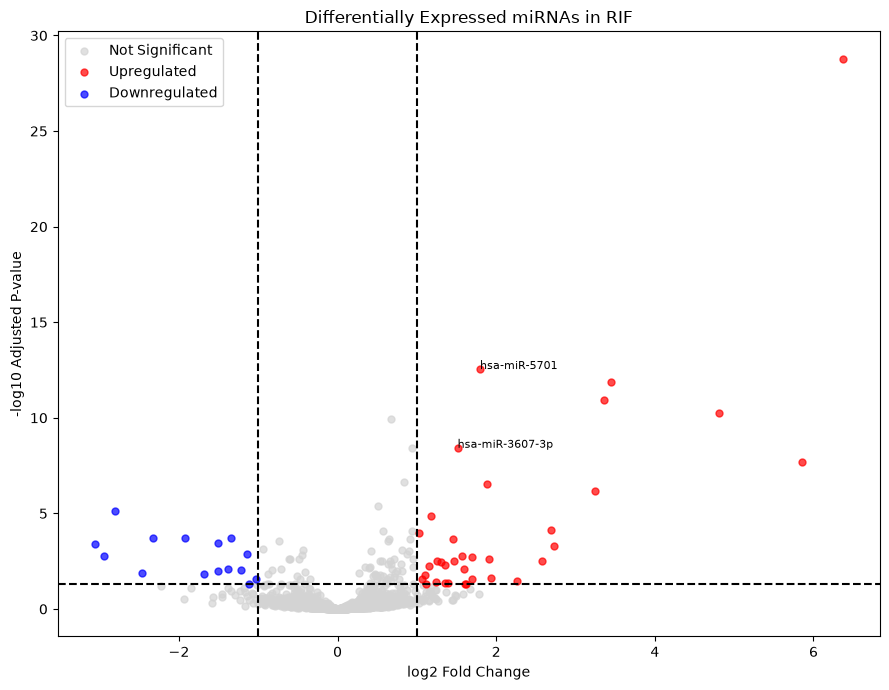

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

res = pd.read_csv(r"F:\downloads microsodt\DESeq2_results.csv")

# Rename 'Unnamed: 0' column to 'miRNA Name' for clarity and consistency
res = res.rename(columns={'Unnamed: 0': 'miRNA Name'})
# Clean miRNA names by replacing '.' with '-' to match the 'important' list format
res['miRNA Name'] = res['miRNA Name'].str.replace('.', '-', regex=False)

res["group"] = "Not Significant"

res.loc[
    (res["padj"] < 0.05) &
    (res["log2FoldChange"] > 1),
    "group"
] = "Upregulated"

res.loc[
    (res["padj"] < 0.05) &
    (res["log2FoldChange"] < -1),
    "group"
] = "Downregulated"

colors = {
    "Not Significant":"lightgray",
    "Upregulated":"red",
    "Downregulated":"blue"
}

plt.figure(figsize=(9,7))

for group, color in colors.items():
    subset = res[res["group"] == group]

    plt.scatter(
        subset["log2FoldChange"],
        -np.log10(subset["padj"]),
        c=color,
        s=25,
        alpha=0.7,
        label=group
    )

plt.axhline(-np.log10(0.05),
            linestyle='--',
            color='black')

plt.axvline(1,
            linestyle='--',
            color='black')

plt.axvline(-1,
            linestyle='--',
            color='black')

important = [
    "hsa-miR-5701",
    "hsa-miR-3607-3p"
]

for _, row in res.iterrows():
    # Check if the miRNA name (now cleaned) is in the important list
    if row["miRNA Name"] in important:

        plt.text(
            row["log2FoldChange"],
            -np.log10(row["padj"]),
            row["miRNA Name"],
            fontsize=8
        )

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 Adjusted P-value")
plt.title("Differentially Expressed miRNAs in RIF")
plt.legend()
plt.tight_layout()
plt.show()

## heat map

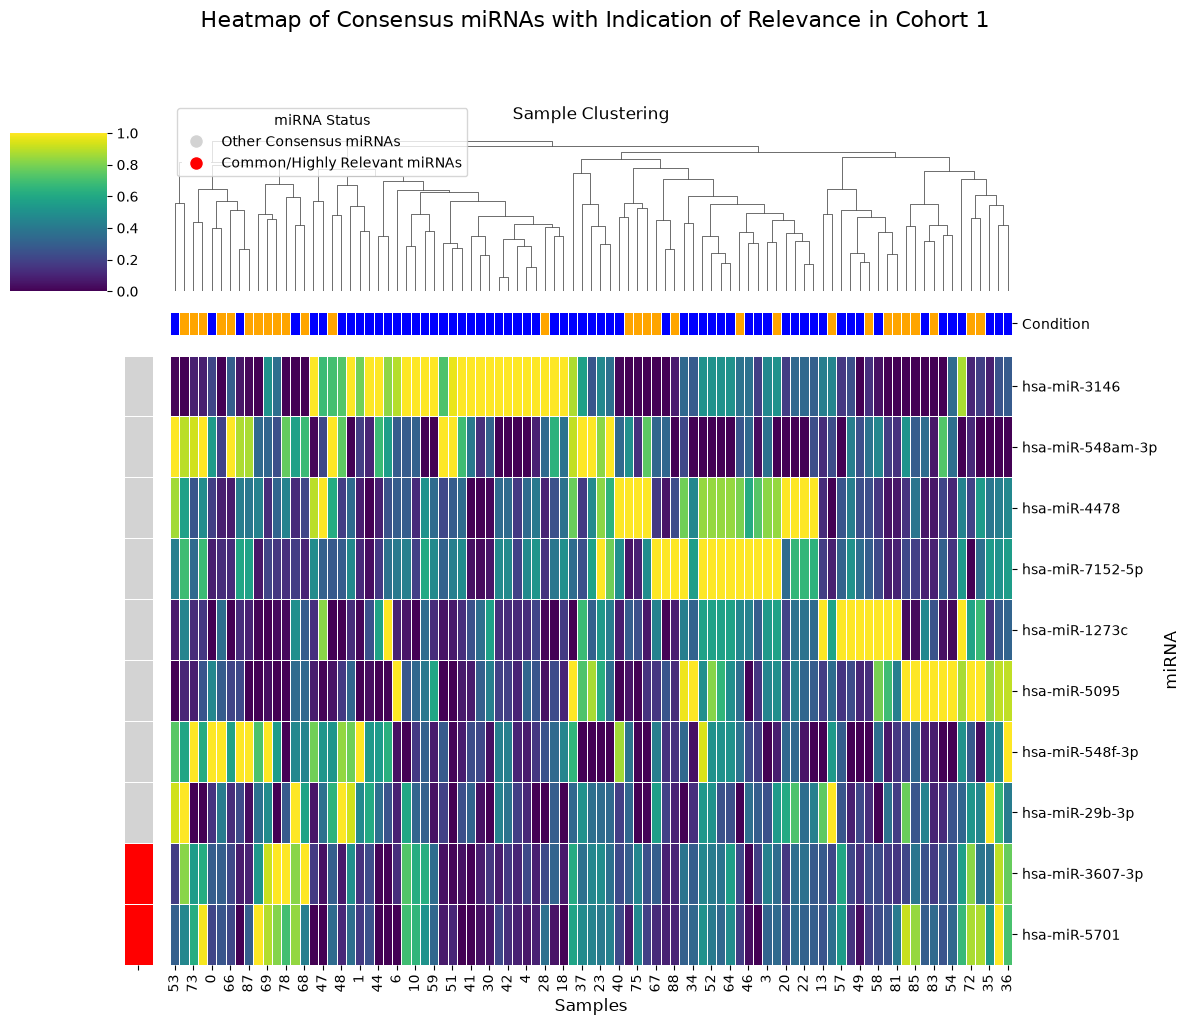

Heatmap of consensus miRNAs with relevance indication and sample conditions saved as 'consensus_mirna_heatmap_relevant_with_conditions.png'


In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Get the list of consensus miRNAs from the 'consensus' set
consensus_mirnas_list = list(consensus)

# Filter the original feature DataFrame (X) to include only consensus miRNAs
# Ensure column names in X match the format in consensus_mirnas_list
# X.columns are already in the correct format (e.g., 'hsa-miR-4478')
heatmap_data = X[consensus_mirnas_list]

# Prepare column annotations for sample conditions (RIF vs. Control)
# Get the 'Condition' from the original final_ml_df for samples corresponding to X
sample_conditions = final_ml_df.set_index(X.index).loc[heatmap_data.index, 'Condition']

# Create a color mapping for conditions
condition_colors_map = {'CONTROL': 'blue', 'IVF': 'orange'}
col_colors = sample_conditions.map(condition_colors_map)

# Create a color map for row annotations (since miRNAs will be rows after transposing)
# Common miRNAs (from DESeq2 integration) will be highlighted as most relevant
row_colors = pd.Series('lightgrey', index=heatmap_data.columns)

# 'common_mirnas' is already defined from previous steps as the intersection of consensus and DESeq2 significant miRNAs
for mirna in common_mirnas:
    if mirna in row_colors.index:
        row_colors[mirna] = 'red'

# Standardize the data (important for heatmaps, especially when comparing expression levels)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_heatmap_data = pd.DataFrame(scaler.fit_transform(heatmap_data), columns=heatmap_data.columns, index=heatmap_data.index)

# Generate the heatmap using seaborn.clustermap for hierarchical clustering
# This provides a comprehensive visualization suitable for research papers
g = sns.clustermap(
    scaled_heatmap_data.T, # Transpose to have miRNAs as rows and samples as columns
    cmap='viridis', # A perceptually uniform colormap
    standard_scale=1, # Standardize across features (miRNAs)
    figsize=(12, 10), # Adjust figure size for publication quality
    row_colors=row_colors, # Apply the highlighting colors to rows (miRNAs)
    col_colors=col_colors, # Apply colors to columns (samples) based on condition
    dendrogram_ratio=(0.1, 0.2), # Adjust dendrogram sizes
    cbar_pos=(0.02, 0.8, 0.03, 0.15), # Position of the color bar (left, bottom, width, height)
    linewidths=0.5, # Add lines between cells
    linecolor='white'
)

# Customize the plot for research paper quality
g.ax_row_dendrogram.set_visible(False) # Hide row dendrogram if not critical for interpretation
g.ax_col_dendrogram.set_title('Sample Clustering', fontsize=12, pad=10) # Title for sample dendrogram
g.ax_heatmap.set_ylabel('miRNA', fontsize=12)
g.ax_heatmap.set_xlabel('Samples', fontsize=12)

# Rotate miRNA labels for readability
g.ax_heatmap.tick_params(axis='y', rotation=0)

# Add a title to the entire figure
g.fig.suptitle('Heatmap of Consensus miRNAs with Indication of Relevance in Cohort 1', y=1.02, fontsize=16)

# Create a legend for the row colors (miRNA relevance)
highlight_patches = [
    plt.Line2D([0], [0], marker='o', color='w', label='Other Consensus miRNAs', markerfacecolor='lightgrey', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Common/Highly Relevant miRNAs', markerfacecolor='red', markersize=10)
]
# Create a legend for the column colors (sample conditions)
condition_patches = [
    plt.Line2D([0], [0], marker='s', color='w', label='CONTROL Samples', markerfacecolor=condition_colors_map['CONTROL'], markersize=10),
    plt.Line2D([0], [0], marker='s', color='w', label='IVF Samples', markerfacecolor=condition_colors_map['IVF'], markersize=10)
]

# Position the legends
g.ax_col_dendrogram.legend(handles=highlight_patches, loc='upper left', bbox_to_anchor=(0, 1.2), fontsize=10, title='miRNA Status')
g.ax_row_dendrogram.legend(handles=condition_patches, loc='upper left', bbox_to_anchor=(0, 1.2), fontsize=10, title='Sample Condition') # Adjusted to ax_row_dendrogram for sample legend

plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent title overlap

# Save the plot as a high-resolution PNG image

plt.show()

print("Heatmap of consensus miRNAs with relevance indication and sample conditions saved as 'consensus_mirna_heatmap_relevant_with_conditions.png'")

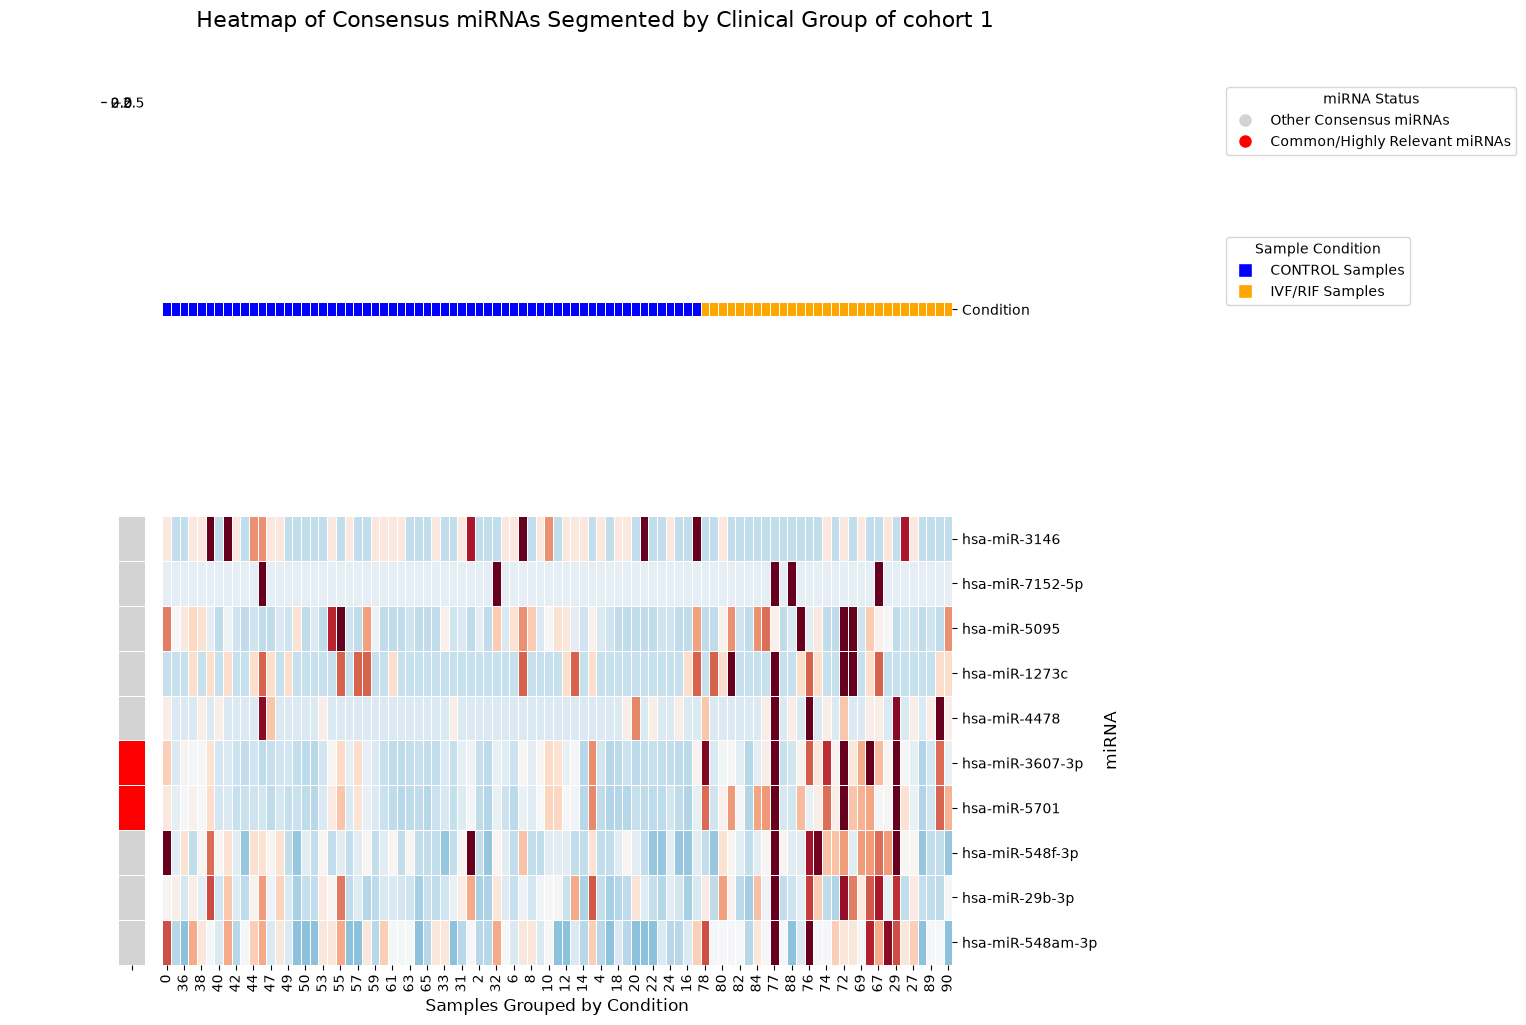

Heatmap successfully generated and saved.


In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare the Data
consensus_mirnas_list = list(consensus)
heatmap_data = X[consensus_mirnas_list].copy()

# 2. Sort Samples Explicitly by Condition (Crucial for visual clarity)
# This attaches the conditions, sorts alphabetically (CONTROL first, then IVF/RIF), and removes the condition column
heatmap_data['Condition'] = final_ml_df.set_index(X.index).loc[heatmap_data.index, 'Condition']
heatmap_data = heatmap_data.sort_values(by='Condition')

# Separate the sorted condition column back out for our color annotations
sample_conditions = heatmap_data['Condition']
heatmap_data = heatmap_data.drop(columns=['Condition'])

# Create column colors mapping based on the newly sorted samples
condition_colors_map = {'CONTROL': 'blue', 'IVF': 'orange'}
col_colors = sample_conditions.map(condition_colors_map)

# 3. Create Row Colors (Highlighting your key miRNAs)
row_colors = pd.Series('lightgrey', index=heatmap_data.columns)
for mirna in common_mirnas:
    if mirna in row_colors.index:
        row_colors[mirna] = 'red'

# 4. Generate the Heatmap
# Note: Removed the manual StandardScaler. We let seaborn handle row-scaling natively via z_score=0.
g = sns.clustermap(
    heatmap_data.T,               # Transpose to have miRNAs as rows and samples as columns
    cmap='RdBu_r',                # Diverging palette (Blue = Down-regulated, Red = Up-regulated)
    z_score=0,                    # Automatically calculates Z-scores across rows (miRNAs)
    center=0,                     # Anchors the exact mean at white/neutral
    col_cluster=False,            # TURN OFF sample clustering to force the Control vs IVF separation
    row_cluster=True,             # Keep miRNA clustering to group similar expression behaviors
    figsize=(12, 10),
    row_colors=row_colors,
    col_colors=col_colors,
    dendrogram_ratio=(0.1, 0.0),  # Set column dendrogram ratio to 0 since col_cluster=False
    cbar_pos=(0.02, 0.8, 0.03, 0.15),
    linewidths=0.5,
    linecolor='white',
    vmin=-2.5, vmax=2.5           # Caps extreme outliers so colors don't get washed out
)

# 5. Customize Plot for Research Quality
g.ax_row_dendrogram.set_visible(False)
g.ax_heatmap.set_ylabel('miRNA', fontsize=12)
g.ax_heatmap.set_xlabel('Samples Grouped by Condition', fontsize=12)

# Rotate labels for readability
g.ax_heatmap.tick_params(axis='y', rotation=0)

# Add title
g.fig.suptitle('Heatmap of Consensus miRNAs Segmented by Clinical Group of cohort 1', y=1.02, fontsize=16)

# 6. Rebuild Legends (Positioned on the main figure to prevent errors)
highlight_patches = [
    plt.Line2D([0], [0], marker='o', color='w', label='Other Consensus miRNAs', markerfacecolor='lightgrey', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Common/Highly Relevant miRNAs', markerfacecolor='red', markersize=10)
]
condition_patches = [
    plt.Line2D([0], [0], marker='s', color='w', label='CONTROL Samples', markerfacecolor='blue', markersize=10),
    plt.Line2D([0], [0], marker='s', color='w', label='IVF/RIF Samples', markerfacecolor='orange', markersize=10)
]

# Attach legends safely outside the plotting area
g.fig.legend(handles=highlight_patches, loc='upper left', bbox_to_anchor=(1.02, 0.95), fontsize=10, title='miRNA Status')
g.fig.legend(handles=condition_patches, loc='upper left', bbox_to_anchor=(1.02, 0.80), fontsize=10, title='Sample Condition')

plt.tight_layout(rect=[0, 0, 0.95, 0.98]) # Leaves room on the right for legends

# Save the plot
plt.show()

print("Heatmap successfully generated and saved.")

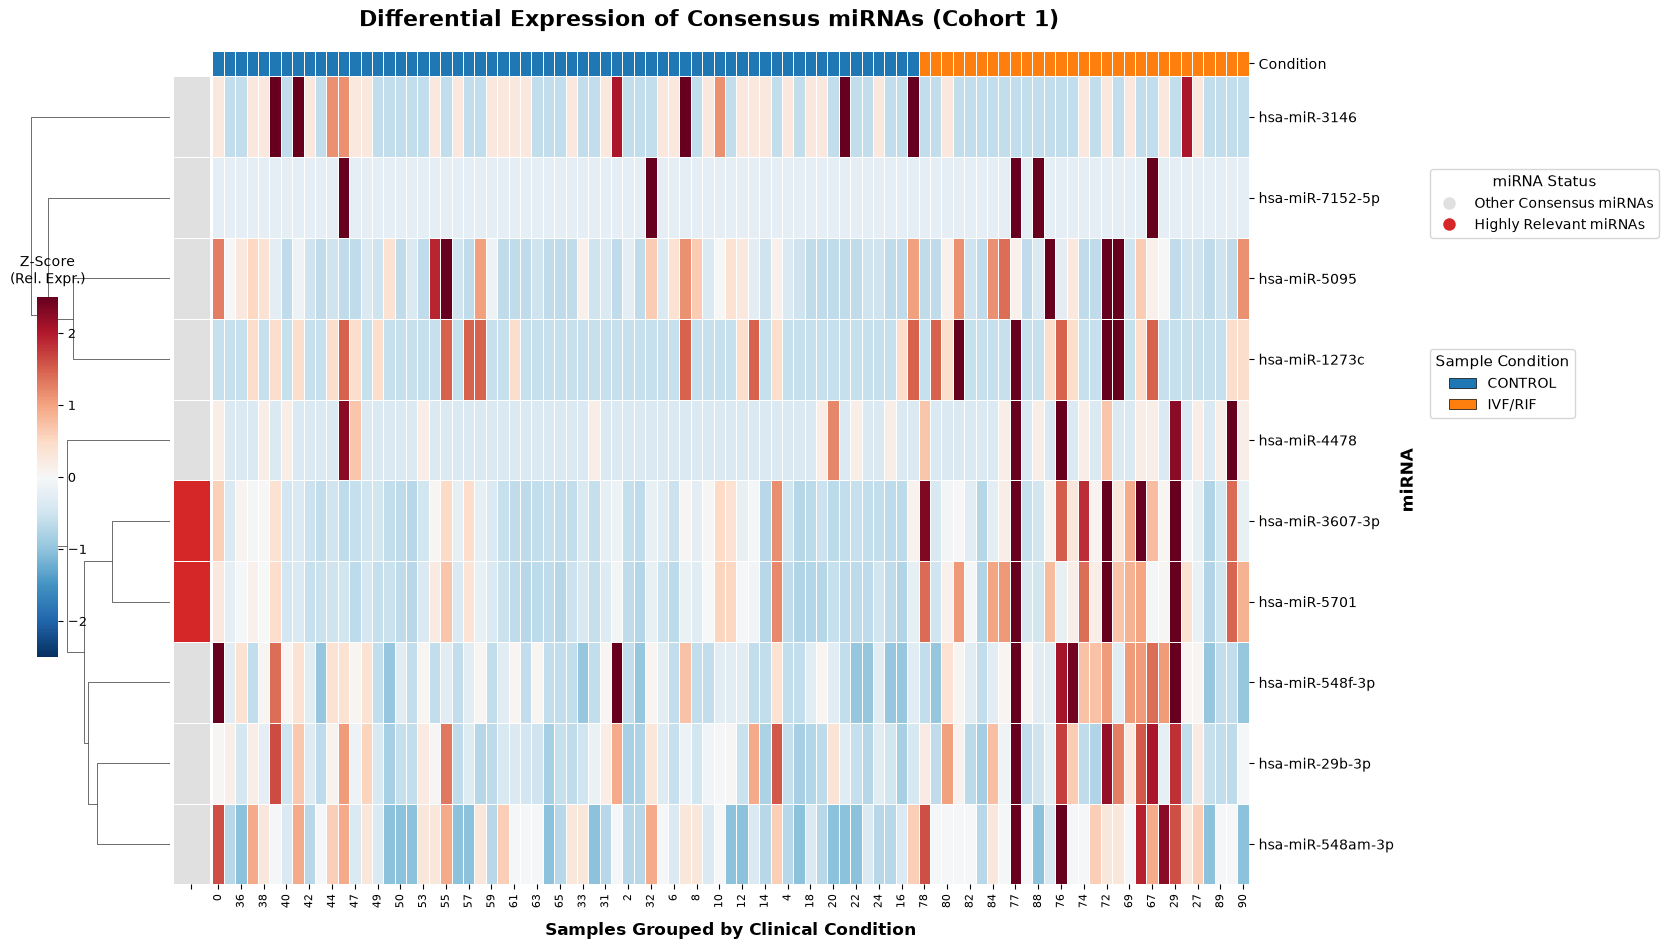

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 1. Prepare and Sort the Data (Same as before)
consensus_mirnas_list = list(consensus)
heatmap_data = X[consensus_mirnas_list].copy()

heatmap_data['Condition'] = final_ml_df.set_index(X.index).loc[heatmap_data.index, 'Condition']
heatmap_data = heatmap_data.sort_values(by='Condition')

sample_conditions = heatmap_data['Condition']
heatmap_data = heatmap_data.drop(columns=['Condition'])

# Color mapping for samples
condition_colors_map = {'CONTROL': '#1f77b4', 'IVF': '#ff7f0e'} # Using standard muted hex colors for pub
col_colors = sample_conditions.map(condition_colors_map)

# Color mapping for key miRNAs
row_colors = pd.Series('#e0e0e0', index=heatmap_data.columns) # Light grey hex
for mirna in common_mirnas:
    if mirna in row_colors.index:
        row_colors[mirna] = '#d62728' # Deep red hex

# 2. Generate the Clustermap with Fixed Grid Spacing
g = sns.clustermap(
    heatmap_data.T,
    cmap='RdBu_r',
    z_score=0,
    center=0,
    col_cluster=False,
    row_cluster=True,
    figsize=(14, 9),              # CHANGED: Wider, shorter aspect ratio fits this data better
    row_colors=row_colors,
    col_colors=col_colors,
    dendrogram_ratio=(0.12, 0.01),# CHANGED: Shrinks the empty top space to 1%, fixing the massive gap
    colors_ratio=0.03,            # CHANGED: Makes the annotation color bars thinner and more elegant
    cbar_pos=(0.02, 0.3, 0.015, 0.4), # CHANGED: Places the colorbar cleanly on the middle-left
    linewidths=0.5,
    linecolor='white',
    vmin=-2.5, vmax=2.5
)

# 3. Clean up the Aesthetics for Publication
# Hide the practically empty column dendrogram axis completely
g.ax_col_dendrogram.set_visible(False)

# Format the Colorbar (Z-score)
g.ax_cbar.set_title('Z-Score\n(Rel. Expr.)', fontsize=10, pad=10)
g.ax_cbar.tick_params(labelsize=9)

# Format the Main Axes
g.ax_heatmap.set_ylabel('miRNA', fontsize=12, fontweight='bold')
g.ax_heatmap.set_xlabel('Samples Grouped by Clinical Condition', fontsize=12, fontweight='bold', labelpad=10)
g.ax_heatmap.tick_params(axis='y', rotation=0, labelsize=10)
g.ax_heatmap.tick_params(axis='x', rotation=90, labelsize=8) # Rotate sample IDs to prevent overlapping

# Main Title
g.fig.suptitle('Differential Expression of Consensus miRNAs (Cohort 1)', y=1.02, fontsize=16, fontweight='bold')

# 4. Build Professional Legends
highlight_patches = [
    Line2D([0], [0], marker='o', color='w', label='Other Consensus miRNAs', markerfacecolor='#e0e0e0', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Highly Relevant miRNAs', markerfacecolor='#d62728', markersize=10)
]
condition_patches = [
    Patch(facecolor='#1f77b4', label='CONTROL', edgecolor='black', linewidth=0.5),
    Patch(facecolor='#ff7f0e', label='IVF/RIF', edgecolor='black', linewidth=0.5)
]

# Place legends cleanly outside the plot area on the right side
g.fig.legend(handles=highlight_patches, loc='upper left', bbox_to_anchor=(1.01, 0.85), fontsize=10, title='miRNA Status', title_fontsize=11)
g.fig.legend(handles=condition_patches, loc='upper left', bbox_to_anchor=(1.01, 0.65), fontsize=10, title='Sample Condition', title_fontsize=11)

# Ensure nothing gets cut off when saving
#plt.tight_layout(rect=[0.05, 0, 0.95, 0.98]) # [left, bottom, right, top]

# Save as high-resolution Tiff/PNG (TIFF is often preferred for journals, but PNG is fine for drafts)
plt.show()

##p log table

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure final_biomarkers_df is available and properly indexed
# If it's already indexed by 'Unnamed: 0' (miRNA names), reset for easier access
if 'Unnamed: 0' not in final_biomarkers_df.columns:
    final_biomarkers_df_reset = final_biomarkers_df.reset_index()
else:
    final_biomarkers_df_reset = final_biomarkers_df.copy()

# Filter for the specific miRNAs requested
target_mirnas = ['hsa-miR-5701', 'hsa-miR-3607-3p']
filtered_df = final_biomarkers_df_reset[final_biomarkers_df_reset['cleaned_mirna_name'].isin(target_mirnas)].copy()

# Calculate Fold Change (2^log2FC)
filtered_df['Fold Change'] = 2**filtered_df['log2FoldChange']

# Determine Regulation
filtered_df['Regulation'] = filtered_df['log2FoldChange'].apply(lambda x: 'Up-regulated' if x > 0 else 'Down-regulated')

# Select and rename columns for the final table
final_table_df = filtered_df[[
    'cleaned_mirna_name',
    'log2FoldChange',
    'Fold Change',
    'pvalue',
    'padj',
    'Regulation'
]].rename(columns={
    'cleaned_mirna_name': 'miRNA',
    'log2FoldChange': 'log2FC',
    'pvalue': 'p-value',
    'padj': 'FDR (padj)'
})

# Format numeric columns for better readability
final_table_df['log2FC'] = final_table_df['log2FC'].round(3)
final_table_df['Fold Change'] = final_table_df['Fold Change'].round(2)
final_table_df['p-value'] = final_table_df['p-value'].apply(lambda x: f'{x:.2e}')
final_table_df['FDR (padj)'] = final_table_df['FDR (padj)'].apply(lambda x: f'{x:.2e}')

display(final_table_df)

# Visualize the table as an image for a research paper
fig, ax = plt.subplots(figsize=(12, len(final_table_df) * 0.7 + 1)) # Adjust size dynamically
ax.axis('off')

# Create the table
table = ax.table(
    cellText=final_table_df.values,
    colLabels=final_table_df.columns,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

ax.set_title('Significance of Key miRNAs in Disease', fontsize=16, pad=20)

plt.tight_layout()
plt.close()

print("Table of key miRNA significance saved as 'key_mirna_significance_table.png'")

,miRNA,log2FC,Fold Change,p-value,FDR (padj),Regulation
0,hsa-miR-5701,1.796,3.47,4.21e-16,2.81e-13,Up-regulated
1,hsa-miR-3607-3p,1.514,2.86,1.94e-11,3.70e-09,Up-regulated


Table of key miRNA significance saved as 'key_mirna_significance_table.png'


In [40]:
# Replace 'e' in scientific notation for better presentation
for col in ['p-value', 'FDR (padj)']:
    final_table_df[col] = final_table_df[col].astype(str).str.replace('e-', ' x 10^-').str.replace('e+', ' x 10^')

# Display the modified DataFrame
display(final_table_df)

# If you wish to save this updated table as an image, you can uncomment and run the following code:
# import matplotlib.pyplot as plt
# fig, ax = plt.subplots(figsize=(12, len(final_table_df) * 0.7 + 1))
# ax.axis('off')
# table = ax.table(
#     cellText=final_table_df.values,
#     colLabels=final_table_df.columns,
#     loc='center',
#     cellLoc='center'
# )
# table.auto_set_font_size(False)
# table.set_fontsize(10)
# table.scale(1.2, 1.2)
# ax.set_title('Significance of Key miRNAs in Disease (Formatted)', fontsize=16, pad=20)
# plt.tight_layout()
# plt.savefig('key_mirna_significance_table_formatted.png', bbox_inches='tight', dpi=300)
# plt.close()
# print("Formatted table saved as 'key_mirna_significance_table_formatted.png'")

,miRNA,log2FC,Fold Change,p-value,FDR (padj),Regulation
0,hsa-miR-5701,1.796,3.47,4.21 x 10^-16,2.81 x 10^-13,Up-regulated
1,hsa-miR-3607-3p,1.514,2.86,1.94 x 10^-11,3.70 x 10^-09,Up-regulated


#

#stability score

In [49]:
# ============================================================
# STABILITY SELECTION
# Repeated SVM + Logistic Regression + SHAP
# ============================================================

import numpy as np
import pandas as pd
import shap

from collections import Counter

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression


# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

NUMBER_OF_RUNS = 100
TOP_K_FEATURES = 20
KBEST_FEATURES = 100

print("Stability selection started...")
print("Number of repeated runs:", NUMBER_OF_RUNS)
print("Top features selected per run:", TOP_K_FEATURES)


# ------------------------------------------------------------
# DATA
# ------------------------------------------------------------

X_original = final_ml_df.drop(columns=metadata_cols).copy()
y_original = final_ml_df["Label"].copy()


# ------------------------------------------------------------
# COUNTERS
# ------------------------------------------------------------

svm_selection_counts = Counter()
lr_selection_counts = Counter()

svm_shap_selection_counts = Counter()
lr_shap_selection_counts = Counter()


# ------------------------------------------------------------
# REPEATED RESAMPLING
# ------------------------------------------------------------

for run_number in range(NUMBER_OF_RUNS):

    print(
        f"Run {run_number + 1}/{NUMBER_OF_RUNS}",
        end="\r"
    )

    # --------------------------------------------------------
    # 1. TRAINING RESAMPLE
    # --------------------------------------------------------

    splitter = StratifiedShuffleSplit(
        n_splits=1,
        test_size=0.20,
        random_state=run_number
    )

    train_indices, _ = next(
        splitter.split(X_original, y_original)
    )

    X_train_raw = X_original.iloc[train_indices]
    y_train = y_original.iloc[train_indices]


    # --------------------------------------------------------
    # 2. STANDARDIZATION
    # --------------------------------------------------------

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        X_train_raw
    )


    # --------------------------------------------------------
    # 3. VARIANCE FILTERING
    # --------------------------------------------------------

    variance_selector = VarianceThreshold(
        threshold=0.01
    )

    X_train_var = variance_selector.fit_transform(
        X_train_scaled
    )

    features_after_variance = X_original.columns[
        variance_selector.get_support()
    ]


    # --------------------------------------------------------
    # 4. SELECT K BEST
    # --------------------------------------------------------

    number_of_available_features = X_train_var.shape[1]

    k_value = min(
        KBEST_FEATURES,
        number_of_available_features
    )

    kbest_selector = SelectKBest(
        score_func=f_classif,
        k=k_value
    )

    X_train_selected = kbest_selector.fit_transform(
        X_train_var,
        y_train
    )

    selected_features_run = features_after_variance[
        kbest_selector.get_support()
    ]


    # --------------------------------------------------------
    # 5. FINAL SCALING
    # --------------------------------------------------------

    final_scaler_run = StandardScaler()

    X_train_final = final_scaler_run.fit_transform(
        X_train_selected
    )


    # ========================================================
    # SVM
    # ========================================================

    svm_model_run = SVC(
        kernel="linear",
        class_weight="balanced",
        random_state=42
    )

    svm_model_run.fit(
        X_train_final,
        y_train
    )


    # --------------------------------------------------------
    # SVM COEFFICIENT IMPORTANCE
    # --------------------------------------------------------

    svm_coefficients = np.abs(
        svm_model_run.coef_[0]
    )

    svm_importance_run = pd.Series(
        svm_coefficients,
        index=selected_features_run
    ).sort_values(
        ascending=False
    )

    svm_top_run = svm_importance_run.head(
        TOP_K_FEATURES
    ).index


    for mirna in svm_top_run:
        svm_selection_counts[mirna] += 1


    # --------------------------------------------------------
    # SVM SHAP
    # --------------------------------------------------------

    svm_explainer_run = shap.LinearExplainer(
        svm_model_run,
        X_train_final
    )

    svm_shap_values_run = (
        svm_explainer_run.shap_values(
            X_train_final
        )
    )

    svm_shap_importance_run = np.abs(
        svm_shap_values_run
    ).mean(axis=0)

    svm_shap_ranking_run = pd.Series(
        svm_shap_importance_run,
        index=selected_features_run
    ).sort_values(
        ascending=False
    )

    svm_shap_top_run = svm_shap_ranking_run.head(
        TOP_K_FEATURES
    ).index


    for mirna in svm_shap_top_run:
        svm_shap_selection_counts[mirna] += 1


    # ========================================================
    # LOGISTIC REGRESSION
    # ========================================================

    lr_model_run = LogisticRegression(
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    )

    lr_model_run.fit(
        X_train_final,
        y_train
    )


    # --------------------------------------------------------
    # LR COEFFICIENT IMPORTANCE
    # --------------------------------------------------------

    lr_coefficients = np.abs(
        lr_model_run.coef_[0]
    )

    lr_importance_run = pd.Series(
        lr_coefficients,
        index=selected_features_run
    ).sort_values(
        ascending=False
    )

    lr_top_run = lr_importance_run.head(
        TOP_K_FEATURES
    ).index


    for mirna in lr_top_run:
        lr_selection_counts[mirna] += 1


    # --------------------------------------------------------
    # LR SHAP
    # --------------------------------------------------------

    lr_explainer_run = shap.LinearExplainer(
        lr_model_run,
        X_train_final
    )

    lr_shap_values_run = (
        lr_explainer_run.shap_values(
            X_train_final
        )
    )

    lr_shap_importance_run = np.abs(
        lr_shap_values_run
    ).mean(axis=0)

    lr_shap_ranking_run = pd.Series(
        lr_shap_importance_run,
        index=selected_features_run
    ).sort_values(
        ascending=False
    )

    lr_shap_top_run = lr_shap_ranking_run.head(
        TOP_K_FEATURES
    ).index


    for mirna in lr_shap_top_run:
        lr_shap_selection_counts[mirna] += 1


print("\nStability selection completed.")

Stability selection started...
Number of repeated runs: 100
Top features selected per run: 20
Run 100/100
Stability selection completed.


In [50]:
# ============================================================
# CALCULATE STABILITY FREQUENCIES
# ============================================================

stability_df = pd.DataFrame({
    "miRNA": X_original.columns
})

stability_df["SVM_Selection_Frequency"] = (
    stability_df["miRNA"]
    .map(svm_selection_counts)
    .fillna(0)
    / NUMBER_OF_RUNS
)

stability_df["SVM_SHAP_Selection_Frequency"] = (
    stability_df["miRNA"]
    .map(svm_shap_selection_counts)
    .fillna(0)
    / NUMBER_OF_RUNS
)

stability_df["LR_Selection_Frequency"] = (
    stability_df["miRNA"]
    .map(lr_selection_counts)
    .fillna(0)
    / NUMBER_OF_RUNS
)

stability_df["LR_SHAP_Selection_Frequency"] = (
    stability_df["miRNA"]
    .map(lr_shap_selection_counts)
    .fillna(0)
    / NUMBER_OF_RUNS
)


# Average stability across all four approaches

stability_df["Combined_Stability"] = (
    stability_df[
        [
            "SVM_Selection_Frequency",
            "SVM_SHAP_Selection_Frequency",
            "LR_Selection_Frequency",
            "LR_SHAP_Selection_Frequency"
        ]
    ].mean(axis=1)
)


# Convert to percentage

stability_df["Combined_Stability_Percent"] = (
    stability_df["Combined_Stability"] * 100
)


# Sort

stability_df = stability_df.sort_values(
    "Combined_Stability",
    ascending=False
).reset_index(drop=True)


display(stability_df.head(20))

,miRNA,SVM_Selection_Frequency,SVM_SHAP_Selection_Frequency,LR_Selection_Frequency,LR_SHAP_Selection_Frequency,Combined_Stability,Combined_Stability_Percent
0,hsa-miR-4418,0.68,0.69,0.79,0.80,0.7400,74.00
1,hsa-miR-5701,0.60,0.57,0.74,0.78,0.6725,67.25
2,hsa-miR-374c-3p,0.55,0.56,0.61,0.61,0.5825,58.25
3,hsa-miR-6844,0.54,0.53,0.58,0.57,0.5550,55.50
4,hsa-miR-3678-3p,0.31,0.31,0.71,0.70,0.5075,50.75
5,hsa-miR-548am-3p,0.52,0.50,0.38,0.41,0.4525,45.25
6,hsa-miR-29b-3p,0.42,0.42,0.43,0.49,0.4400,44.00
7,hsa-miR-4444,0.42,0.44,0.42,0.46,0.4350,43.50
8,hsa-miR-6758-3p,0.38,0.35,0.42,0.41,0.3900,39.00
9,hsa-miR-320c,0.53,0.51,0.16,0.18,0.3450,34.50


In [51]:
# ============================================================
# MERGE EXISTING ML IMPORTANCE SCORES
# ============================================================

svm_score_df = feature_importance_df[
    ["miRNA", "Importance"]
].rename(
    columns={
        "Importance": "SVM_Coefficient"
    }
)

svm_shap_score_df = shap_df[
    ["miRNA", "SHAP_Importance"]
].rename(
    columns={
        "SHAP_Importance": "SVM_SHAP"
    }
)

lr_score_df = lr_biomarkers[
    ["miRNA", "Coefficient_Importance"]
].rename(
    columns={
        "Coefficient_Importance": "LR_Coefficient"
    }
)

lr_shap_score_df = lr_shap_df[
    ["miRNA", "SHAP_Importance"]
].rename(
    columns={
        "SHAP_Importance": "LR_SHAP"
    }
)


# Start with stability table

priority_df = stability_df.copy()


# Merge SVM

priority_df = priority_df.merge(
    svm_score_df,
    on="miRNA",
    how="left"
)


# Merge SVM SHAP

priority_df = priority_df.merge(
    svm_shap_score_df,
    on="miRNA",
    how="left"
)


# Merge Logistic Regression

priority_df = priority_df.merge(
    lr_score_df,
    on="miRNA",
    how="left"
)


# Merge LR SHAP

priority_df = priority_df.merge(
    lr_shap_score_df,
    on="miRNA",
    how="left"
)


display(priority_df.head())

,miRNA,SVM_Selection_Frequency,SVM_SHAP_Selection_Frequency,LR_Selection_Frequency,LR_SHAP_Selection_Frequency,Combined_Stability,Combined_Stability_Percent,SVM_Coefficient,SVM_SHAP,LR_Coefficient,LR_SHAP
0,hsa-miR-4418,0.68,0.69,0.79,0.80,0.7400,74.00,0.343540,0.164357,0.394033,0.188514
1,hsa-miR-5701,0.60,0.57,0.74,0.78,0.6725,67.25,0.381984,0.427146,0.794248,0.888151
2,hsa-miR-374c-3p,0.55,0.56,0.61,0.61,0.5825,58.25,0.359805,0.186663,0.327494,0.169900
3,hsa-miR-6844,0.54,0.53,0.58,0.57,0.5550,55.50,0.264222,0.120301,0.390988,0.178018
4,hsa-miR-3678-3p,0.31,0.31,0.71,0.70,0.5075,50.75,NaN,NaN,NaN,NaN


In [52]:
print(feature_importance_df.columns)

Index(['miRNA', 'Importance'], dtype='str')


In [55]:
print(res.columns.tolist())


['miRNA Name', 'baseMean', 'log2FoldChange', 'lfcSE', 'stat', 'pvalue', 'padj', 'group']


In [56]:
# ============================================================
# DESEQ2 SCORES
# ============================================================

deseq_scores = res.copy()

deseq_scores["miRNA"] = (
    deseq_scores['miRNA Name']
    .astype(str)
    .str.replace(".", "-", regex=False)
)


deseq_scores = deseq_scores[
    [
        "miRNA",
        "log2FoldChange",
        "pvalue",
        "padj"
    ]
]


# Merge DESeq2 results

priority_df = priority_df.merge(
    deseq_scores,
    on="miRNA",
    how="left"
)


display(priority_df.head())

,miRNA,SVM_Selection_Frequency,SVM_SHAP_Selection_Frequency,LR_Selection_Frequency,LR_SHAP_Selection_Frequency,Combined_Stability,Combined_Stability_Percent,SVM_Coefficient,SVM_SHAP,LR_Coefficient,LR_SHAP,log2FoldChange,pvalue,padj
0,hsa-miR-4418,0.68,0.69,0.79,0.80,0.7400,74.00,0.343540,0.164357,0.394033,0.188514,2.733638,1.114464e-05,4.951937e-04
1,hsa-miR-5701,0.60,0.57,0.74,0.78,0.6725,67.25,0.381984,0.427146,0.794248,0.888151,1.796157,4.209939e-16,2.805924e-13
2,hsa-miR-374c-3p,0.55,0.56,0.61,0.61,0.5825,58.25,0.359805,0.186663,0.327494,0.169900,1.352637,3.320798e-03,4.290993e-02
3,hsa-miR-6844,0.54,0.53,0.58,0.57,0.5550,55.50,0.264222,0.120301,0.390988,0.178018,1.466911,9.464497e-02,NaN
4,hsa-miR-3678-3p,0.31,0.31,0.71,0.70,0.5075,50.75,NaN,NaN,NaN,NaN,1.120222,2.223804e-01,NaN


In [57]:
# ============================================================
# DESEQ2 EVIDENCE SCORE
# ============================================================

priority_df["Absolute_log2FC"] = (
    priority_df["log2FoldChange"].abs()
)

priority_df["Minus_log10_padj"] = (
    -np.log10(
        priority_df["padj"].clip(lower=1e-300)
    )
)


# Percentile-based scores

priority_df["DESeq_Effect_Score"] = (
    priority_df["Absolute_log2FC"]
    .rank(pct=True)
)

priority_df["DESeq_Significance_Score"] = (
    priority_df["Minus_log10_padj"]
    .rank(pct=True)
)


priority_df["DESeq_Evidence_Score"] = (
    priority_df[
        [
            "DESeq_Effect_Score",
            "DESeq_Significance_Score"
        ]
    ].mean(axis=1)
)

In [58]:
# ============================================================
# DESEQ2 EVIDENCE SCORE
# ============================================================

priority_df["Absolute_log2FC"] = (
    priority_df["log2FoldChange"].abs()
)

priority_df["Minus_log10_padj"] = (
    -np.log10(
        priority_df["padj"].clip(lower=1e-300)
    )
)


# Percentile-based scores

priority_df["DESeq_Effect_Score"] = (
    priority_df["Absolute_log2FC"]
    .rank(pct=True)
)

priority_df["DESeq_Significance_Score"] = (
    priority_df["Minus_log10_padj"]
    .rank(pct=True)
)


priority_df["DESeq_Evidence_Score"] = (
    priority_df[
        [
            "DESeq_Effect_Score",
            "DESeq_Significance_Score"
        ]
    ].mean(axis=1)
)

In [60]:
print(priority_df.columns)

Index(['miRNA', 'SVM_Selection_Frequency', 'SVM_SHAP_Selection_Frequency',
       'LR_Selection_Frequency', 'LR_SHAP_Selection_Frequency',
       'Combined_Stability', 'Combined_Stability_Percent', 'SVM_Coefficient',
       'SVM_SHAP', 'LR_Coefficient', 'LR_SHAP', 'log2FoldChange', 'pvalue',
       'padj', 'Absolute_log2FC', 'Minus_log10_padj', 'DESeq_Effect_Score',
       'DESeq_Significance_Score', 'DESeq_Evidence_Score'],
      dtype='str')


In [63]:
# ============================================================
# FINAL PRIORITY SCORE
# ============================================================

priority_df["Priority_Score"] = (

    0.15 * priority_df["SVM_Coefficient"]

    + 0.15 * priority_df["SVM_SHAP"]

    + 0.15 * priority_df["LR_Coefficient"]

    + 0.15 * priority_df["LR_SHAP"]

    + 0.20 * priority_df["DESeq_Evidence_Score"]

    + 0.20 * priority_df["Combined_Stability"]

)

In [64]:
priority_df = priority_df.sort_values(
    "Priority_Score",
    ascending=False
).reset_index(drop=True)

priority_df["Priority_Rank"] = (
    priority_df.index + 1
)

In [65]:
# ============================================================
# FINAL COMMON miRNAs
# ============================================================

final_common_mirnas_df = priority_df[
    priority_df["miRNA"].isin(common_mirnas)
].copy()


final_common_mirnas_df = final_common_mirnas_df.sort_values(
    "Priority_Score",
    ascending=False
).reset_index(drop=True)


final_common_mirnas_df["Final_Rank"] = (
    final_common_mirnas_df.index + 1
)


display(final_common_mirnas_df)

,miRNA,SVM_Selection_Frequency,SVM_SHAP_Selection_Frequency,LR_Selection_Frequency,LR_SHAP_Selection_Frequency,Combined_Stability,Combined_Stability_Percent,SVM_Coefficient,SVM_SHAP,LR_Coefficient,...,pvalue,padj,Absolute_log2FC,Minus_log10_padj,DESeq_Effect_Score,DESeq_Significance_Score,DESeq_Evidence_Score,Priority_Score,Priority_Rank,Final_Rank
0,hsa-miR-5701,0.60,0.57,0.74,0.78,0.6725,67.25,0.381984,0.427146,0.794248,...,4.209939e-16,2.805924e-13,1.796157,12.551924,0.989714,0.999250,0.994482,0.707126,1,1
1,hsa-miR-3607-3p,0.19,0.16,0.28,0.29,0.2300,23.00,0.382498,0.315774,0.638348,...,1.943972e-11,3.701878e-09,1.513542,8.431578,0.983900,0.995499,0.989699,0.523482,6,2


In [67]:
# ============================================================
# PUBLICATION-READY TABLE
# ============================================================

publication_table = final_common_mirnas_df[
    [
        "Final_Rank",
        "miRNA",

        "SVM_Coefficient",
        "SVM_SHAP",

        "LR_Coefficient",
        "LR_SHAP",

        "SVM_Selection_Frequency",
        "LR_Selection_Frequency",
        "Combined_Stability",

        "log2FoldChange",
        "pvalue",
        "padj",

        "DESeq_Evidence_Score",
        "Priority_Score"
    ]
].copy()


display(publication_table)

,Final_Rank,miRNA,SVM_Coefficient,SVM_SHAP,LR_Coefficient,LR_SHAP,SVM_Selection_Frequency,LR_Selection_Frequency,Combined_Stability,log2FoldChange,pvalue,padj,DESeq_Evidence_Score,Priority_Score
0,1,hsa-miR-5701,0.381984,0.427146,0.794248,0.888151,0.60,0.74,0.6725,1.796157,4.209939e-16,2.805924e-13,0.994482,0.707126
1,2,hsa-miR-3607-3p,0.382498,0.315774,0.638348,0.526993,0.19,0.28,0.2300,1.513542,1.943972e-11,3.701878e-09,0.989699,0.523482
